# StormScope Satellite and Radar Nowcasting

StormScope inference workflow with GOES satellite imagery and MRMS radar data.

This example will demonstrate how to run coupled inference to generate
predictions using StormScope models with both GOES and MRMS data sources.

In this example you will learn:

- How to instantiate StormScope models for GOES and MRMS
- Creating GOES and MRMS data sources
- Running iterative prognostic forecasts
- Plotting a single GOES channel with MRMS overlay

## Set Up
This example shows a minimal StormScope workflow with GOES satellite imagery
and MRMS radar data. We build two models:

- [`earth2studio.models.px.StormScopeGOES`][earth2studio.models.px.StormScopeGOES] to forecast GOES channels.
- [`earth2studio.models.px.StormScopeMRMS`][earth2studio.models.px.StormScopeMRMS] to forecast radar
  reflectivity (and a gridded GLM lightning channel).

In the CONUS nowcasting (``3km_10min``) configuration the GOES model is
"pure obs" (no external conditioning), while the MRMS model is conditioned on
GOES — the GOES model provides that conditioning during the rollout via
``call_with_conditioning``. The MRMS model additionally has a GLM lightning
channel (``glm_density``) as part of its state, which we assemble for the
initial condition and which then evolves autoregressively over the rollout.

In [1]:
import os
from datetime import datetime

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import trange

from earth2studio.data import GOES, MRMS, GOESGLMGrid, fetch_data
from earth2studio.models.px.stormscope import (
    StormScopeBase,
    StormScopeGOES,
    StormScopeMRMS,
)


We use the CONUS nowcasting variant (``3km_10min``), the recommended default.
The GOES model is "pure obs" (no external conditioning), forecasting the eight
ABI channels from their recent history. The MRMS model forecasts
``[refc, refc_base, glm_density]`` conditioned on GOES, and additionally
consumes a Geostationary Lightning Mapper (GLM) channel that is both an input
(observation history) and a predicted output. The GLM field comes from
[`earth2studio.data.GOESGLMGrid`][earth2studio.data.GOESGLMGrid], a gridded 0.1-degree lightning
product; the model bilinearly regrids it onto the model grid internally.

Other selectable variants (see ``StormScope*.list_available_models``):

- "3km_10min": CONUS nowcasting, 3 km / 10 min (recommended, default)
- "6km_1hr": legacy 6 km / 60 min nearcasting

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "3km_10min"

package = StormScopeBase.load_default_package()

# GOES nowcast model: pure-obs, no external conditioning source needed.
# We enable automatic mixed precision (autocast) and compile the model for faster inference.
model = StormScopeGOES.load_model(
    package=package,
    conditioning_data_source=None,
    model_name=model_name,
    amp=True,
    compile=True,
)
model = model.to(device)
model.eval()

# MRMS+GLM nowcast model: conditioned on GOES, with a gridded GLM source. Here
# we drive it via call_with_conditioning, so glm_data_source is used only to
# fetch the initial GLM state (via fetch_glm); the bilinear GLM interpolator is
# built lazily on the first call. (In a standalone __call__/create_iterator run
# the same glm_data_source would inject GLM automatically each step.)
model_mrms = StormScopeMRMS.load_model(
    package=package,
    conditioning_data_source=GOES(),
    glm_data_source=GOESGLMGrid(satellite="east"),
    model_name=model_name,
    amp=True,
    compile=True,
)
model_mrms = model_mrms.to(device)
model_mrms.eval()


2026-08-12 17:25:01.370 | WARNING  | earth2studio.models.px.stormscope:__init__:193 - No conditioning data source was provided to StormScope; set the conditioning_data_source attribute of the model before running inference with iterator mode, or use the call_with_conditioning method.


## Setup GOES Data Source and Interpolators
We fetch GOES data for the model inputs and build interpolators that map the
GOES grid and GFS grid into the StormScope model grid. StormScope operates on
the HRRR grid, or a downsampled version of it, and for convenience each model
defines grid coordinates `model.latitudes` and `model.longitudes` to help with
the regridding functionality.

In [3]:
start_date = [np.datetime64(datetime(2024, 1, 8, 18, 0, 0))]
goes_satellite = "goes16"
scan_mode = "C"

variables = model.input_coords()["variable"]
lat_out = model.latitudes.detach().cpu().numpy()
lon_out = model.longitudes.detach().cpu().numpy()

goes = GOES(satellite=goes_satellite, scan_mode=scan_mode)
goes_lat, goes_lon = GOES.grid(satellite=goes_satellite, scan_mode=scan_mode)

# The GOES nowcast model is pure-obs (no external conditioning), so only an input
# interpolator (GOES grid -> model grid) is needed.
model.build_input_interpolator(goes_lat, goes_lon)

in_coords = model.input_coords()

# Fetch GOES data (left on the native GOES grid; the model regrids internally)
x, x_coords = fetch_data(
    goes,
    time=start_date,
    variable=np.array(variables),
    lead_time=in_coords["lead_time"],
    device=device,
)


2026-08-12 17:25:20.898 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:643 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (0.0).


Fetching GOES data: 100%|██████████| 1/1 [00:00<00:00,  3.05it/s]


## Setup MRMS + GLM Data Sources and Assemble the State
The MRMS+GLM model forecasts ``[refc, refc_base, glm_density]``. The radar
channels come from [`earth2studio.data.MRMS`][earth2studio.data.MRMS]; the GLM channel comes
from [`earth2studio.data.GOESGLMGrid`][earth2studio.data.GOESGLMGrid]. Because we drive the rollout
with ``call_with_conditioning`` (the coupled path), we own the full initial
state: we fetch radar and GLM, regrid each onto the shared model grid (GLM uses
bilinear regridding, unlike the nearest-neighbor radar/satellite path), and
stack them in the model's ``variables`` order (radar channels first, GLM last).
After the first step GLM flows autoregressively from the model's own
predictions, exactly like the radar channels. (If you instead ran the MRMS
model standalone via ``__call__`` / ``create_iterator``, ``glm_data_source``
would inject GLM automatically and only radar would need to be assembled here.)

In [4]:
mrms = MRMS()
mrms_in_coords = model_mrms.input_coords()

# Radar state channels (everything in `variables` that is not a GLM channel)
radar_vars = np.array(
    [v for v in model_mrms.variables if v not in set(model_mrms.glm_variables)]
)
x_radar, x_coords_radar = fetch_data(
    mrms,
    time=start_date,
    variable=radar_vars,
    lead_time=mrms_in_coords["lead_time"],
    device=device,
)

# Interpolators: radar/GOES use nearest-neighbor; GLM is built lazily (bilinear)
# inside fetch_glm.
model_mrms.build_input_interpolator(x_coords_radar["lat"], x_coords_radar["lon"])
model_mrms.build_conditioning_interpolator(goes_lat, goes_lon)

# Regrid the radar channels onto the model grid (nearest-neighbor).
x_radar = model_mrms.input_interp(x_radar)

# Fetch + bilinearly regrid the GLM observation window onto the model grid. The
# returned counts are physical (the model applies log1p internally).
glm_coords = mrms_in_coords.copy()
glm_coords["time"] = np.array(start_date)
x_glm, _ = model_mrms.fetch_glm(glm_coords, device=device)

# Stack into the full MRMS+GLM state on the model grid, matching `variables` order
# ([refc, refc_base, glm_density]); the variable axis is dim 2 of [T, L, C, H, W].
x_mrms = torch.cat([x_radar, x_glm], dim=2).to(dtype=torch.float32)

# Coords now describe the model grid (y/x) with the full variable list. Start from
# the fetched radar coords so the dim order matches, then swap in y/x and variables.
x_coords_mrms = x_coords_radar.copy()
x_coords_mrms["variable"] = np.array(model_mrms.variables)
del x_coords_mrms["lat"], x_coords_mrms["lon"]
x_coords_mrms["y"] = model_mrms.y
x_coords_mrms["x"] = model_mrms.x


2026-08-12 17:25:24.581 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedBaseReflectivityQC_00.50/20240108/MRMS_MergedBaseReflectivityQC_00.50_20240108-170959.grib2.gz
2026-08-12 17:25:29.075 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20240108/MRMS_MergedReflectivityQCComposite_00.50_20240108-171038.grib2.gz
2026-08-12 17:25:33.650 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedBaseReflectivityQC_00.50/20240108/MRMS_MergedBaseReflectivityQC_00.50_20240108-172015.grib2.gz
2026-08-12 17:25:38.168 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20240108/MRMS_MergedReflectivityQCComposite_00.50_20240108-172040.grib2.gz
2026-08-12 17:25:42.754 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetchi

Fetching GLM L2 LCFA files: 100%|██████████| 17/17 [00:00<00:00, 23112.86it/s]


## Add Batch Dimension
The models expect a batch dimension: [B, T, L, C, H, W]. Up to GPU memory limits,
this can be increased to produce multiple ensemble members.

In [5]:
batch_size = 1
if x.dim() == 5:
    x = x.unsqueeze(0).repeat(batch_size, 1, 1, 1, 1, 1)
    x_coords["batch"] = np.arange(batch_size)
    x_coords.move_to_end("batch", last=False)
if x_mrms.dim() == 5:
    x_mrms = x_mrms.unsqueeze(0).repeat(batch_size, 1, 1, 1, 1, 1)
    x_coords_mrms["batch"] = np.arange(batch_size)
    x_coords_mrms.move_to_end("batch", last=False)

x = x.to(dtype=torch.float32)
x_mrms = x_mrms.to(dtype=torch.float32)


## Execute the Workflow
Since the StormScope coupled inference is a bit more involved, we will use
a custom forecast loop rather than a built-in workflow. Here, the GOES model
predicts future satellite imagery, and the MRMS model predicts radar
reflectivity (and GLM) conditioned on GOES (initially the raw data, then the
forecasted GOES imagery) via ``call_with_conditioning``.

In [6]:
y, y_coords = x, x_coords
y_mrms, y_coords_mrms = x_mrms, x_coords_mrms

n_steps = 2
for step_idx in trange(n_steps, desc="Forecast steps"):
    # Run one prognostic step with the GOES model
    y_pred, y_pred_coords = model(y, y_coords)

    # Run one prognostic step with the MRMS model conditioned on GOES
    y_mrms_pred, y_coords_mrms_pred = model_mrms.call_with_conditioning(
        y_mrms, y_coords_mrms, conditioning=y, conditioning_coords=y_coords
    )

    # Advance the sliding window for the next step: drop the oldest input frame
    # and append the new prediction. We assign directly into the loop carry
    # variables (y/y_mrms) and keep y_pred/y_mrms_pred pointing at the single
    # latest prediction (lead time +step), which is what we plot below.
    y, y_coords = model.next_input(y_pred, y_pred_coords, y, y_coords)
    y_mrms, y_coords_mrms = model_mrms.next_input(
        y_mrms_pred, y_coords_mrms_pred, y_mrms, y_coords_mrms
    )


Forecast steps: 100%|██████████| 2/2 [03:34<00:00, 107.47s/it]


## Post Processing
Let's plot the final forecast step: GOES abi13c (Clean IR 10.35um) in
grayscale with MRMS reflectivity (refc) overlaid.

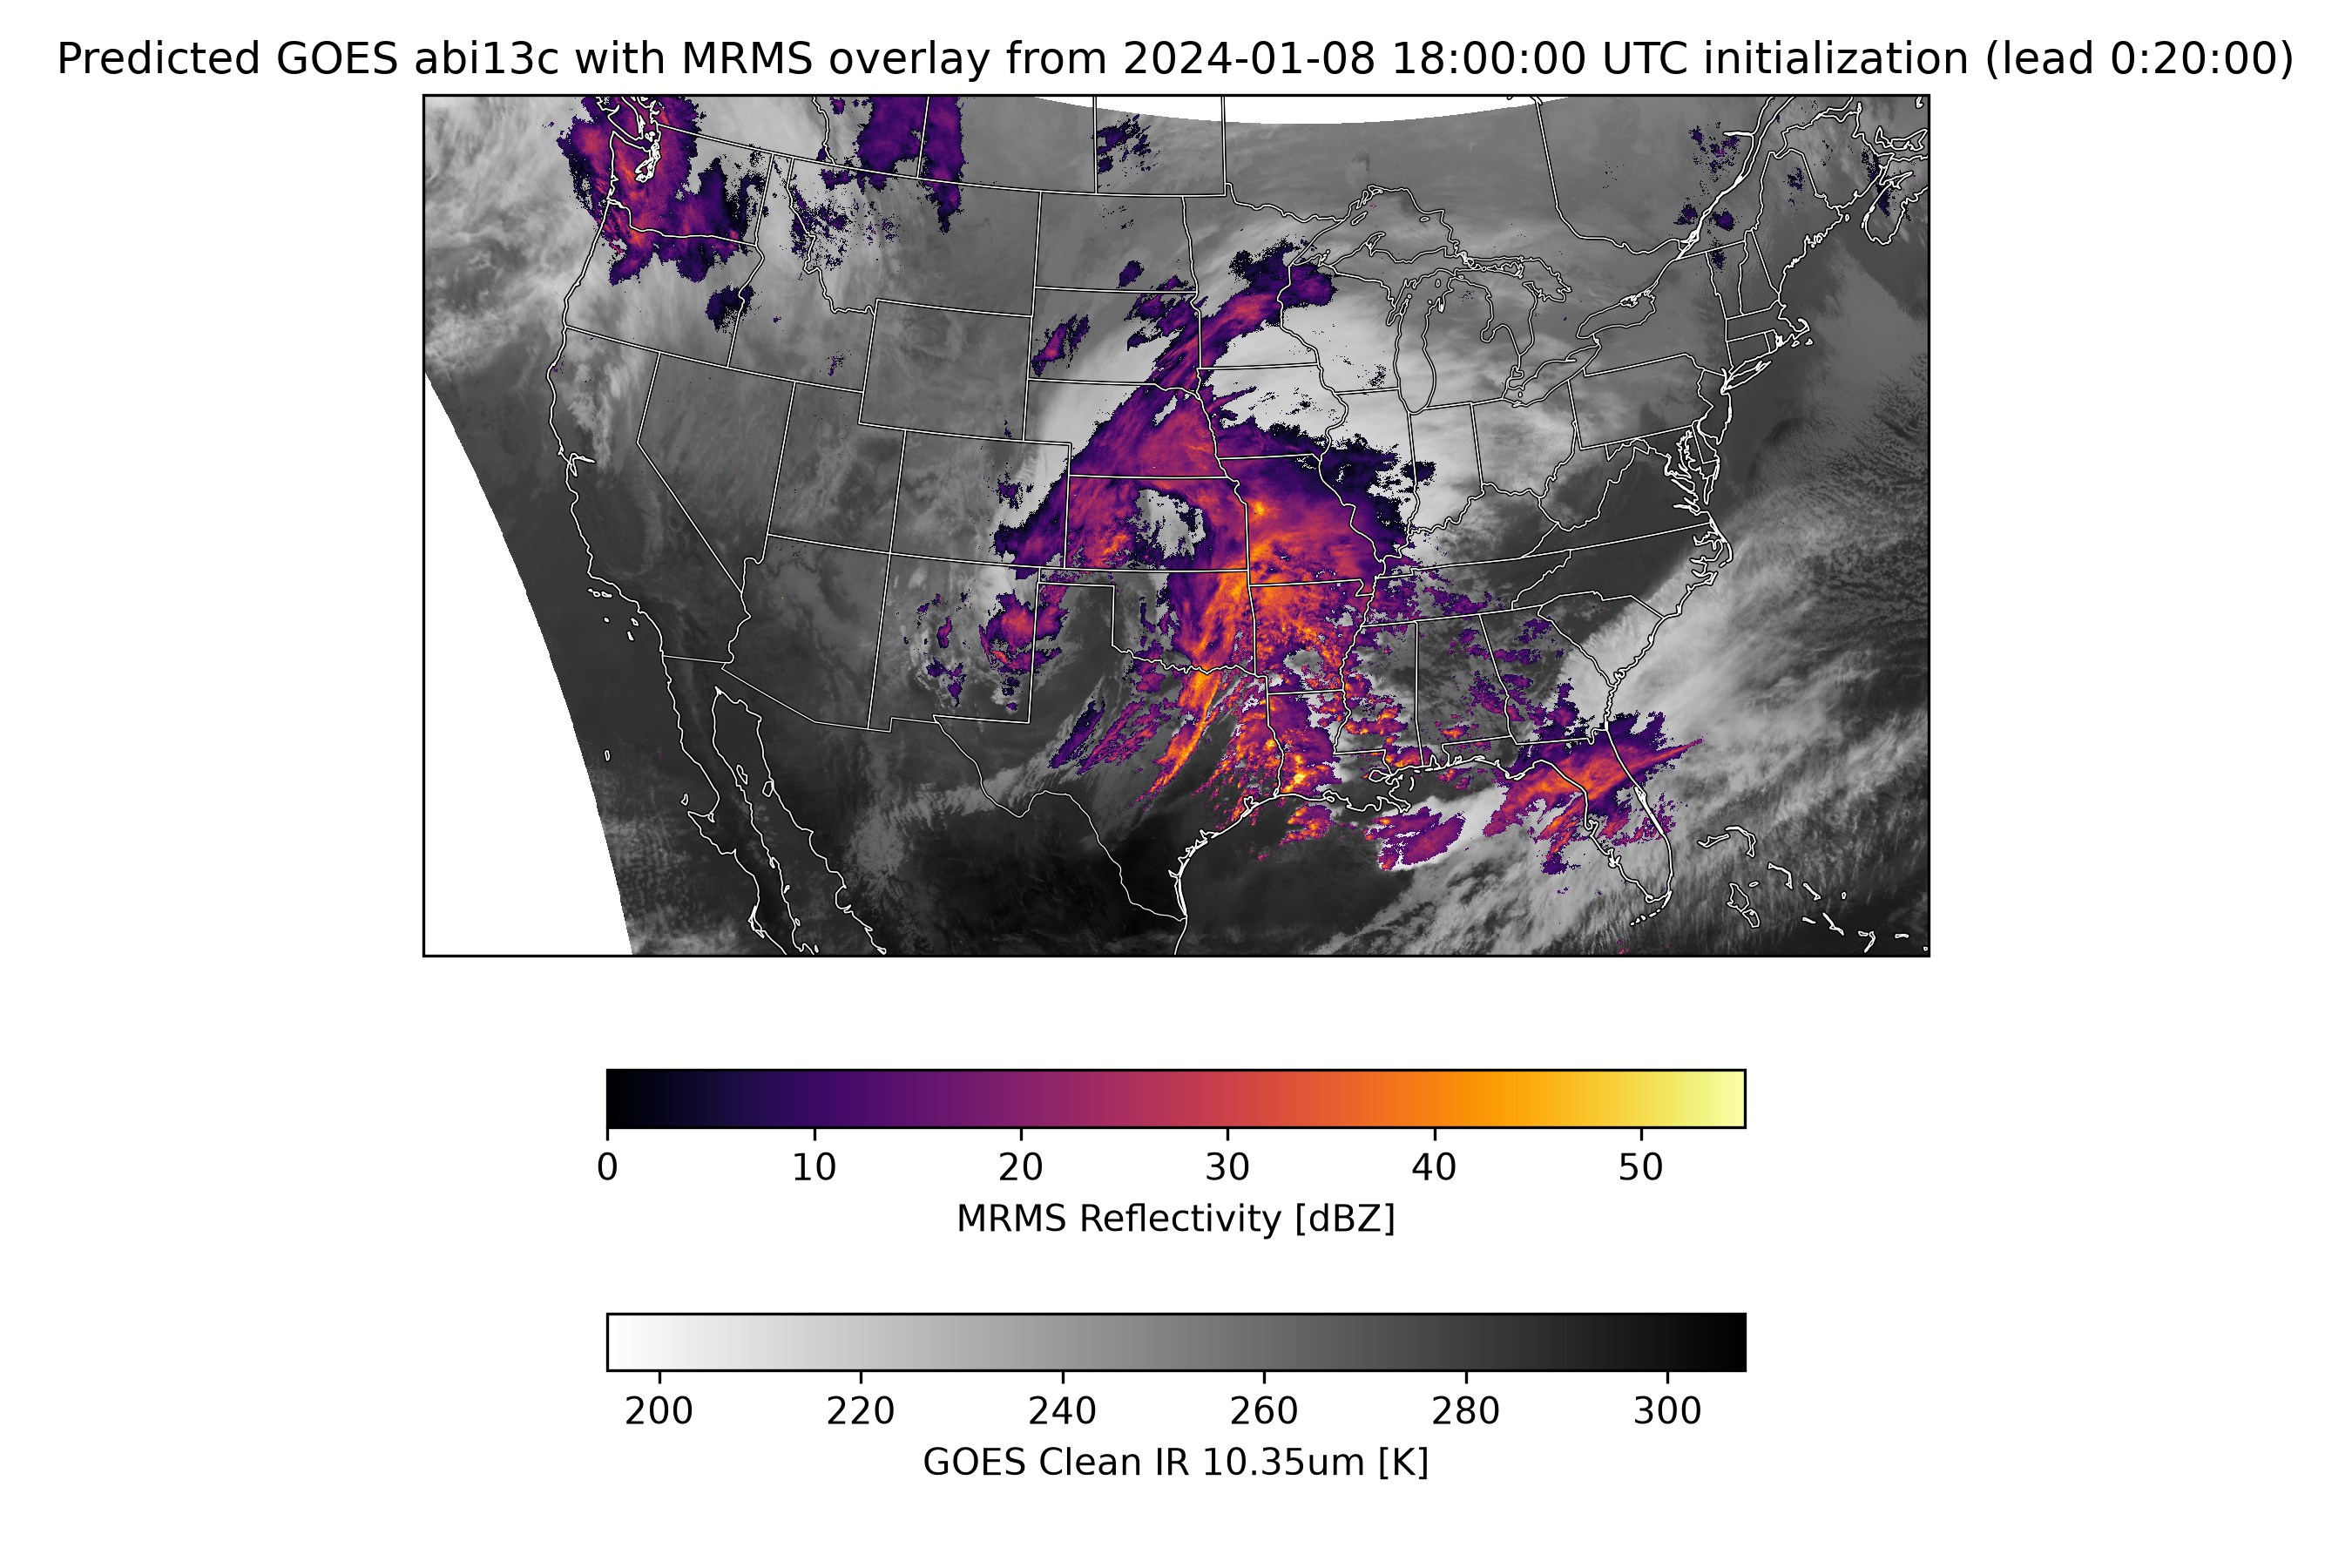

In [7]:
goes_channel = "abi13c"
goes_ch_idx = list(model.variables).index(goes_channel)
mrms_ch_idx = list(model_mrms.variables).index("refc")

# Nan-fill invalid gridpoints
y_pred = torch.where(model.valid_mask, y_pred, torch.nan)
y_mrms_pred = torch.where(model_mrms.valid_mask, y_mrms_pred, torch.nan)

# Prepare HRRR Lambert Conformal projection
proj_hrrr = ccrs.LambertConformal(
    central_longitude=262.5,
    central_latitude=38.5,
    standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)
plt.figure(figsize=(9, 6))
ax = plt.axes(projection=proj_hrrr)

# Dual layer coast/state lines for better day/night visibility
# Black halo (thicker)
ax.coastlines(color="black", linewidth=1.2)
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.0)

# White inner line (thinner)
ax.coastlines(color="white", linewidth=0.4)
ax.add_feature(cfeature.STATES, edgecolor="white", linewidth=0.3)

field = y_pred[0, 0, 0, goes_ch_idx].detach().cpu().numpy()
im = ax.pcolormesh(
    lon_out,
    lat_out,
    field,
    transform=ccrs.PlateCarree(),
    cmap="gray_r",
    shading="auto",
)

# Overlay MRMS on top of GOES
field_mrms = y_mrms_pred[0, 0, 0, mrms_ch_idx]
field_mrms = (
    torch.where(~model.valid_mask, torch.nan, field_mrms).detach().cpu().numpy()
)
field_mrms = np.where(field_mrms <= 0, np.nan, field_mrms)
im_mrms = ax.pcolormesh(
    lon_out,
    lat_out,
    field_mrms,
    transform=ccrs.PlateCarree(),
    cmap="inferno",
    shading="auto",
    vmin=0.0,
    vmax=55.0,
)
plt.colorbar(
    im,
    label="GOES Clean IR 10.35um [K]",
    orientation="horizontal",
    pad=0.05,
    shrink=0.5,
)
plt.colorbar(
    im_mrms,
    label="MRMS Reflectivity [dBZ]",
    orientation="horizontal",
    pad=0.1,
    shrink=0.5,
)

time = y_pred_coords["time"][0].item()
lead_time = y_pred_coords["lead_time"][0]
plt.title(
    f"Predicted GOES {goes_channel} with MRMS overlay from {time} UTC "
    f"initialization (lead {lead_time.astype('timedelta64[m]').item()})"
)

plt.tight_layout()
plt.savefig("outputs/03_stormscope_goes_example.png", dpi=300)
